<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/Set_4(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

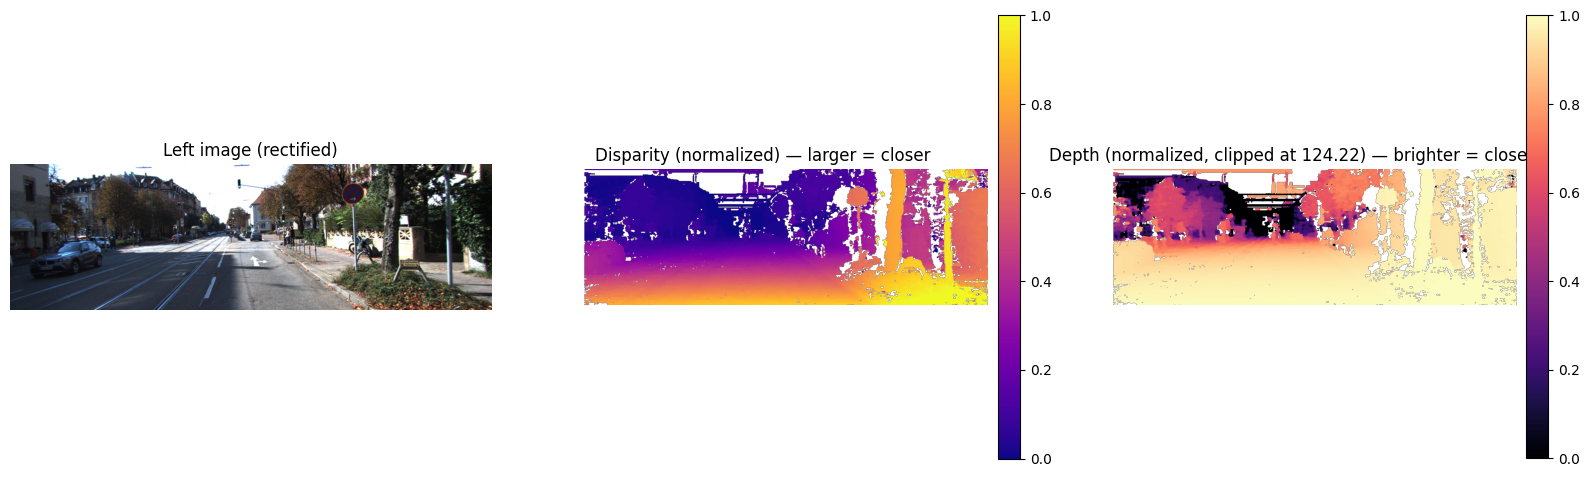

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_disparity_sgbm(imgL, imgR,
                           min_disp=0, num_disp=128, block_size=5,
                           P1=None, P2=None, disp12_max_diff=1,
                           pre_filter_cap=63, uniqueness_ratio=10,
                           speckle_window_size=100, speckle_range=32,
                           mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY):

    # Ensure inputs are grayscale
    if imgL.ndim == 3:
        imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    else:
        imgL_gray = imgL
    if imgR.ndim == 3:
        imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    else:
        imgR_gray = imgR

    # num_disp must be divisible by 16
    if num_disp % 16 != 0:
        num_disp = (num_disp // 16 + 1) * 16

    if P1 is None:
        P1 = 8 * 1 * block_size * block_size
    if P2 is None:
        P2 = 32 * 1 * block_size * block_size

    sgbm = cv2.StereoSGBM_create(
        minDisparity=min_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=P1,
        P2=P2,
        disp12MaxDiff=disp12_max_diff,
        preFilterCap=pre_filter_cap,
        uniquenessRatio=uniqueness_ratio,
        speckleWindowSize=speckle_window_size,
        speckleRange=speckle_range,
        mode=mode
    )

    disp16 = sgbm.compute(imgL_gray, imgR_gray)  # int16 with 4 fractional bits
    # convert to float disparity in pixels
    disparity = disp16.astype(np.float32) / 16.0
    return disparity

def disparity_to_depth(disparity, fx, baseline, invalid_val=np.nan, min_disp=0.1):

    depth = np.full(disparity.shape, invalid_val, dtype=np.float32)
    # valid mask: disparity > small threshold to avoid division by zero
    valid = disparity > min_disp
    depth[valid] = (fx * baseline) / disparity[valid]
    return depth, valid

def normalize_for_display(img, clip_percent=(2,98)):

    lo = np.percentile(img[~np.isnan(img)], clip_percent[0]) if np.any(~np.isnan(img)) else 0.0
    hi = np.percentile(img[~np.isnan(img)], clip_percent[1]) if np.any(~np.isnan(img)) else 1.0
    hi = max(hi, lo + 1e-6)
    norm = (img - lo) / (hi - lo)
    norm = np.clip(norm, 0.0, 1.0)
    return norm

def visualize_disparity_and_depth(left_img, right_img, disparity, depth, valid_mask,
                                  disp_cmap='plasma', depth_cmap='magma', vmax_depth=None):

    plt.figure(figsize=(16,6))

    # Left image
    plt.subplot(1,3,1)
    if left_img.ndim == 3:
        plt.imshow(cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(left_img, cmap='gray')
    plt.title("Left image (rectified)")
    plt.axis('off')

    # Disparity: we normalize for display. Note: larger disparity -> closer objects
    disp_vis = disparity.copy()
    disp_vis[disparity <= 0] = np.nan
    disp_norm = normalize_for_display(disp_vis)
    plt.subplot(1,3,2)
    im2 = plt.imshow(disp_norm, cmap=disp_cmap)
    plt.title("Disparity (normalized) — larger = closer")
    plt.axis('off')
    plt.colorbar(im2, fraction=0.046, pad=0.02)

    # Depth: optionally clip far values for visualization
    depth_vis = depth.copy()
    depth_vis[~valid_mask] = np.nan
    if vmax_depth is None:
        # set a reasonably visible max depth to clip visualization (e.g., 80th percentile)
        finite = depth_vis[np.isfinite(depth_vis)]
        if finite.size > 0:
            vmax_depth = np.percentile(finite, 95)
        else:
            vmax_depth = 100.0
    # invert depth for visualization (so closer = bright)
    depth_clip = np.copy(depth_vis)
    depth_clip[np.isfinite(depth_clip)] = np.minimum(depth_clip[np.isfinite(depth_clip)], vmax_depth)
    depth_norm = 1.0 - normalize_for_display(depth_clip)  # invert: closer -> larger value
    plt.subplot(1,3,3)
    im3 = plt.imshow(depth_norm, cmap=depth_cmap)
    plt.title(f"Depth (normalized, clipped at {vmax_depth:.2f}) — brighter = closer")
    plt.axis('off')
    plt.colorbar(im3, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

def run_stereo_pipeline(left_path, right_path, fx, baseline,
                        sgbm_params=None, visualize=True):
    """
    Top-level function. Returns disparity (float px), depth (same unit as baseline), valid mask.
    """
    left = cv2.imread(left_path)
    right = cv2.imread(right_path)
    if left is None or right is None:
        raise FileNotFoundError("Could not read left or right image — check paths.")

    # If color images, convert to grayscale for matching (KITTI often uses grayscale rectified pairs)
    left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY) if left.ndim == 3 else left
    right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY) if right.ndim == 3 else right

    # Unpack sgbm params or use defaults
    if sgbm_params is None:
        sgbm_params = {
            'min_disp': 0,
            'num_disp': 128,   # must be multiple of 16
            'block_size': 5,
            'P1': None,
            'P2': None,
            'disp12_max_diff': 1,
            'pre_filter_cap': 63,
            'uniqueness_ratio': 10,
            'speckle_window_size': 100,
            'speckle_range': 32,
            'mode': cv2.STEREO_SGBM_MODE_SGBM_3WAY
        }

    disp = compute_disparity_sgbm(left_gray, right_gray,
                                  min_disp=sgbm_params['min_disp'],
                                  num_disp=sgbm_params['num_disp'],
                                  block_size=sgbm_params['block_size'],
                                  P1=sgbm_params['P1'],
                                  P2=sgbm_params['P2'],
                                  disp12_max_diff=sgbm_params['disp12_max_diff'],
                                  pre_filter_cap=sgbm_params['pre_filter_cap'],
                                  uniqueness_ratio=sgbm_params['uniqueness_ratio'],
                                  speckle_window_size=sgbm_params['speckle_window_size'],
                                  speckle_range=sgbm_params['speckle_range'],
                                  mode=sgbm_params['mode'])

    # Convert to depth
    depth, valid = disparity_to_depth(disp, fx, baseline, invalid_val=np.nan, min_disp=0.1)

    if visualize:
        visualize_disparity_and_depth(left, right, disp, depth, valid)

    return {
        'left_img': left, 'right_img': right,
        'disparity_px': disp, 'depth_m': depth, 'valid_mask': valid
    }

if __name__ == "__main__":
    # EXAMPLE: replace with your paths and intrinsics
    IMG_LEFT = "/content/000001_10_L.png"
    IMG_RIGHT = "/content/000001_10_R.png"
    # Example KITTI-ish intrinsics (replace with your calibrated values):
    FX = 718.8560       # focal length in pixels (example)
    BASELINE = 0.54     # baseline in meters (example)

    out = run_stereo_pipeline(IMG_LEFT, IMG_RIGHT, FX, BASELINE, visualize=True)
    # Access arrays: out['disparity_px'], out['depth_m'], out['valid_mask']


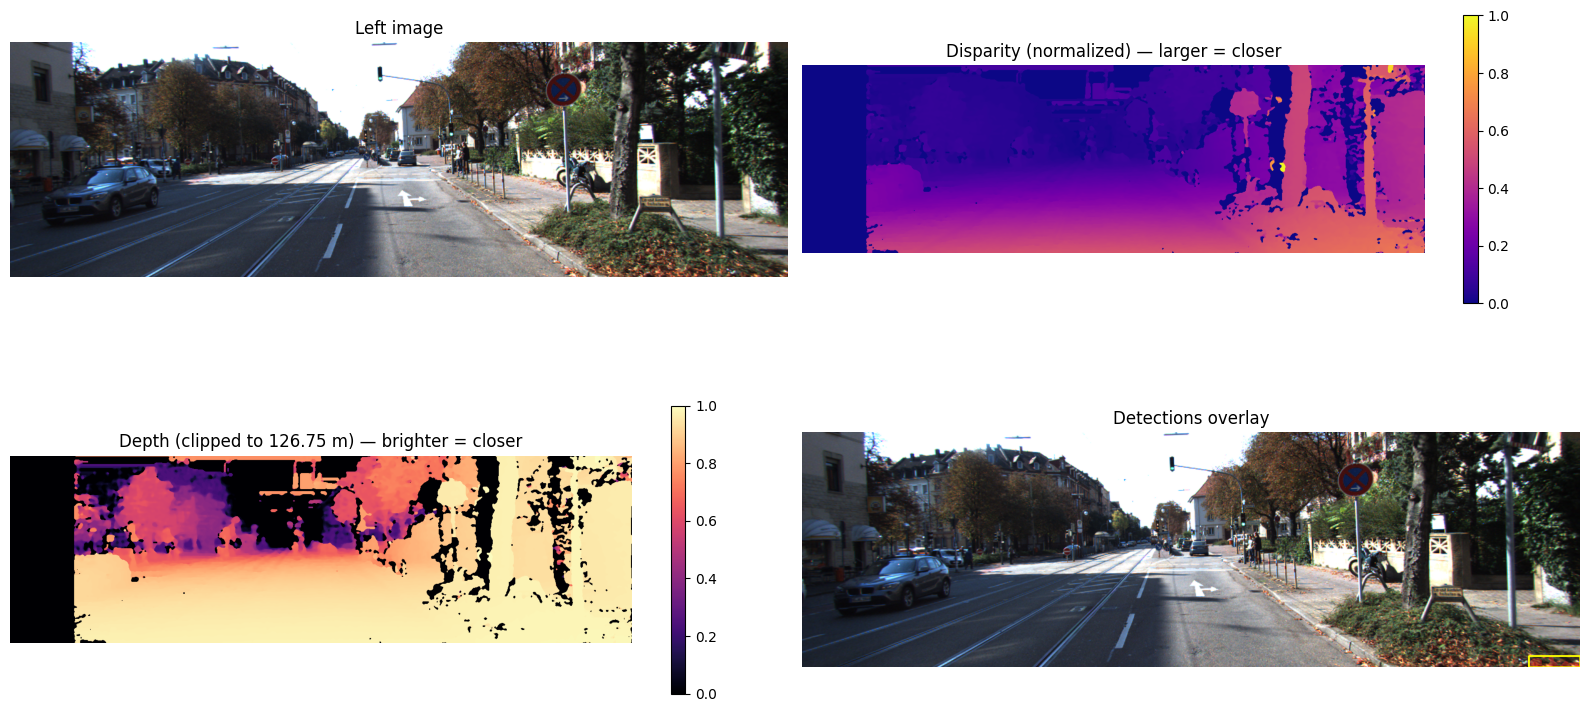

Detected obstacle pixels: 686; number of boxes: 1
Bounding boxes (x,y,w,h,area):
  (1160, 357, 82, 18, np.int32(686))


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import log10

def compute_disparity_sgbm(left_gray, right_gray,
                           min_disp=0, num_disp=128, block_size=5,
                           P1=None, P2=None, disp12_max_diff=1,
                           pre_filter_cap=63, uniqueness_ratio=10,
                           speckle_window_size=100, speckle_range=32,
                           mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY):
    # Ensure num_disp is divisible by 16
    if num_disp % 16 != 0:
        num_disp = (num_disp // 16 + 1) * 16
    if P1 is None:
        P1 = 8 * 1 * block_size * block_size
    if P2 is None:
        P2 = 32 * 1 * block_size * block_size

    sgbm = cv2.StereoSGBM_create(
        minDisparity=min_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=P1, P2=P2,
        disp12MaxDiff=disp12_max_diff,
        preFilterCap=pre_filter_cap,
        uniquenessRatio=uniqueness_ratio,
        speckleWindowSize=speckle_window_size,
        speckleRange=speckle_range,
        mode=mode
    )

    disp16 = sgbm.compute(left_gray, right_gray)   # int16 with 4 fractional bits
    disparity = disp16.astype(np.float32) / 16.0   # disparity in pixels (float)
    return disparity

def disparity_to_depth(disparity, fx, baseline, min_disp=0.1):
    """
    Convert disparity (pixels) to depth (same unit as baseline).
    disparity values <= min_disp produce nan depth.
    """
    depth = np.full(disparity.shape, np.nan, dtype=np.float32)
    valid = disparity > min_disp
    depth[valid] = (fx * baseline) / disparity[valid]
    return depth, valid

def postprocess_disparity(disparity, median_ksize=5):
    """Optional denoise: median filter on disparity (operates on finite values only)."""
    # mask invalid
    disp = disparity.copy()
    mask = np.isfinite(disp)
    # fill invalid temporarily with 0 for median (we'll restore mask)
    temp = np.where(mask, disp, 0.0).astype(np.float32)
    temp = cv2.medianBlur(temp, median_ksize)
    # keep original invalid locations as NaN
    temp[~mask] = np.nan
    return temp

def detect_obstacles_by_depth(depth_map, valid_mask, depth_threshold,
                              morph_kernel_size=7, min_area_px=300):

    # binary mask of near pixels
    near = np.zeros(depth_map.shape, dtype=np.uint8)
    near[np.logical_and(valid_mask, depth_map < depth_threshold)] = 255

    # morphological clean-up
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    near = cv2.morphologyEx(near, cv2.MORPH_OPEN, k)
    near = cv2.morphologyEx(near, cv2.MORPH_CLOSE, k)

    # connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(near, connectivity=8)
    bboxes = []
    clean_mask = np.zeros_like(near)
    for lbl in range(1, num_labels):
        area = stats[lbl, cv2.CC_STAT_AREA]
        x = int(stats[lbl, cv2.CC_STAT_LEFT])
        y = int(stats[lbl, cv2.CC_STAT_TOP])
        w = int(stats[lbl, cv2.CC_STAT_WIDTH])
        h = int(stats[lbl, cv2.CC_STAT_HEIGHT])
        if area >= min_area_px:
            bboxes.append((x, y, w, h, area))
            clean_mask[labels == lbl] = 255

    return clean_mask, bboxes, labels

def overlay_detections_on_image(img_bgr, obstacle_mask, bboxes,
                                mask_color=(0,0,200), bbox_color=(0,255,255),
                                alpha=0.4):

    vis = img_bgr.copy()
    if img_bgr.ndim == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)

    # colored mask
    color_layer = np.zeros_like(vis, dtype=np.uint8)
    color_layer[obstacle_mask > 0] = mask_color
    blended = cv2.addWeighted(vis, 1.0, color_layer, alpha, 0)
    # draw bboxes
    for (x, y, w, h, area) in bboxes:
        cv2.rectangle(blended, (x, y), (x+w, y+h), bbox_color, 2)
        # area and approximate depth info could be annotated later
    return blended

def visualize_results(left_bgr, disparity, depth, valid_mask, obstacle_mask, bboxes,
                      depth_clip=None):

    plt.figure(figsize=(16,9))
    # left
    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(left_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Left image"); plt.axis('off')

    # disparity
    disp_vis = disparity.copy()
    disp_vis[~np.isfinite(disp_vis)] = 0.0
    # normalize disparity for display
    if np.nanmax(disp_vis) - np.nanmin(disp_vis) > 0:
        disp_norm = (disp_vis - np.nanmin(disp_vis)) / (np.nanmax(disp_vis) - np.nanmin(disp_vis))
    else:
        disp_norm = disp_vis
    plt.subplot(2,2,2)
    plt.imshow(disp_norm, cmap='plasma')
    plt.title("Disparity (normalized) — larger = closer"); plt.axis('off'); plt.colorbar(shrink=0.6)

    # depth
    depth_vis = depth.copy()
    depth_vis[~np.isfinite(depth_vis)] = np.nan
    # limit clipping for visualization
    if depth_clip is None:
        finite = depth_vis[np.isfinite(depth_vis)]
        depth_clip = np.percentile(finite, 95) if finite.size > 0 else 100.0
    d = depth_vis.copy()
    d[np.isfinite(d)] = np.minimum(d[np.isfinite(d)], depth_clip)
    # invert for brighter=closer
    d_norm = 1.0 - (d - np.nanmin(d[np.isfinite(d)]) + 1e-6) / (depth_clip - np.nanmin(d[np.isfinite(d)]) + 1e-6)
    d_norm[~np.isfinite(d_norm)] = 0.0
    plt.subplot(2,2,3)
    plt.imshow(d_norm, cmap='magma')
    plt.title(f"Depth (clipped to {depth_clip:.2f} m) — brighter = closer"); plt.axis('off'); plt.colorbar(shrink=0.6)

    # overlay
    overlay = overlay_detections_on_image(left_bgr, obstacle_mask, bboxes)
    plt.subplot(2,2,4)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Detections overlay"); plt.axis('off')

    plt.tight_layout()
    plt.show()

def stereo_obstacle_detection_pipeline(left_path, right_path, fx, baseline,
                                       depth_threshold=5.0,
                                       sgbm_params=None,
                                       median_ksize=5,
                                       morph_kernel_size=7, min_area_px=300,
                                       visualize=True):

    left_bgr = cv2.imread(left_path)
    right_bgr = cv2.imread(right_path)
    if left_bgr is None or right_bgr is None:
        raise FileNotFoundError("Could not read left/right images.")

    left_gray = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2GRAY)

    if sgbm_params is None:
        sgbm_params = {'min_disp':0, 'num_disp':128, 'block_size':5,
                       'P1':None, 'P2':None, 'disp12_max_diff':1,
                       'pre_filter_cap':63, 'uniqueness_ratio':10,
                       'speckle_window_size':100, 'speckle_range':32,
                       'mode':cv2.STEREO_SGBM_MODE_SGBM_3WAY}

    disparity = compute_disparity_sgbm(left_gray, right_gray,
                                       min_disp=sgbm_params['min_disp'],
                                       num_disp=sgbm_params['num_disp'],
                                       block_size=sgbm_params['block_size'],
                                       P1=sgbm_params['P1'],
                                       P2=sgbm_params['P2'],
                                       disp12_max_diff=sgbm_params['disp12_max_diff'],
                                       pre_filter_cap=sgbm_params['pre_filter_cap'],
                                       uniqueness_ratio=sgbm_params['uniqueness_ratio'],
                                       speckle_window_size=sgbm_params['speckle_window_size'],
                                       speckle_range=sgbm_params['speckle_range'],
                                       mode=sgbm_params['mode'])

    # Optional denoise
    if median_ksize and median_ksize > 1:
        disparity = postprocess_disparity(disparity, median_ksize=median_ksize)

    # convert to depth
    depth, valid_mask = disparity_to_depth(disparity, fx, baseline, min_disp=0.1)

    # detect obstacles
    obstacle_mask, bboxes, labels = detect_obstacles_by_depth(depth, valid_mask, depth_threshold,
                                                              morph_kernel_size=morph_kernel_size,
                                                              min_area_px=min_area_px)

    # visualize
    if visualize:
        visualize_results(left_bgr, disparity, depth, valid_mask, obstacle_mask, bboxes)

    # statistics
    count_pixels = int(np.sum(obstacle_mask > 0))
    print(f"Detected obstacle pixels: {count_pixels}; number of boxes: {len(bboxes)}")
    if len(bboxes) > 0:
        print("Bounding boxes (x,y,w,h,area):")
        for b in bboxes:
            print(" ", b)

    return {
        'left_bgr': left_bgr,
        'right_bgr': right_bgr,
        'disparity': disparity,
        'depth': depth,
        'valid_mask': valid_mask,
        'obstacle_mask': obstacle_mask,
        'bboxes': bboxes,
        'labels': labels,
        'depth_threshold': depth_threshold
    }


# Example usage:
if __name__ == "__main__":
    LEFT_IMG_PATH = "/content/000001_10_L.png"
    RIGHT_IMG_PATH = "/content/000001_10_R.png"
    FX = 718.8560      # example KITTI focal length in px
    BASELINE = 0.54    # example KITTI baseline in meters
    DEPTH_THRESHOLD = 5.0  # meters

    results = stereo_obstacle_detection_pipeline(LEFT_IMG_PATH, RIGHT_IMG_PATH,
                                                 FX, BASELINE,
                                                 depth_threshold=DEPTH_THRESHOLD,
                                                 visualize=True)
